In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path = "/home/ravjot/football/output-videos/cropped_player.jpg"
image = cv2.imread(image_path)
# Convert the image from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

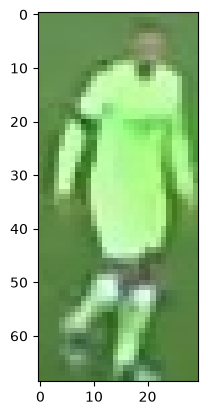

In [4]:
plt.imshow(image)
plt.show()

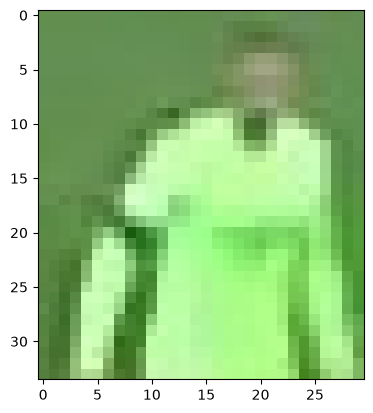

In [ ]:
#taking the top half of the image to avoid the background
top_half = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half)
plt.show()


Cluster image into two clusters using Kmeans

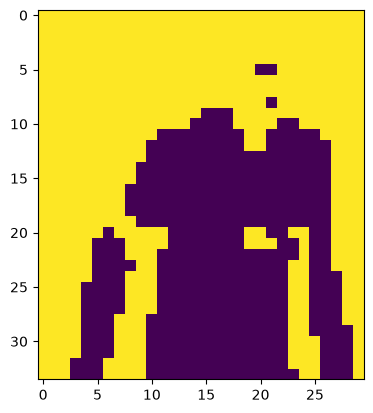

In [ ]:
#resahpe the image to a 2D array of pixels
image_2d = top_half.reshape((-1, 3))

#perform k-means clustering to find the dominant colors
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# Get the cluster labels
labels = kmeans.labels_

#reshape the labels back to the original image shape
clustered_image = labels.reshape(top_half.shape[0], top_half.shape[1])

#display the clustered image
plt.imshow(clustered_image)
plt.show()

In [ ]:
# Find the most common cluster in the corners of the image
# which is likely to be the background color
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_clusters = max(set(corner_clusters), key=corner_clusters.count)
print(f"Non-player cluster: {non_player_clusters}")

Non-player cluster: 1


In [8]:
player_cluster = 1-non_player_clusters
print(player_cluster)

0


In [ ]:
kmeans.cluster_centers_[player_cluster]#it will give the RGB values of the player cluster

array([176.26840855, 244.2304038 , 150.6152019 ])